# Resort Churn Prediction — Classical ML + Optuna

**Goal.** Predict the binary `Churned` flag for resort guests in `resort_test.csv` and write a `submission.csv` file containing `GuestID,Churned` rows.

**Workflow.**
1. Load the raw train / test CSVs straight from GitHub.
2. Clean the data: cap obvious outliers in the spend columns, parse `BookingDate`, split the composite `Room` code, and add missingness indicators.
3. Build a `ColumnTransformer` so the *same* preprocessing is applied to train and test.
4. Run a quick 5-fold cross-validated bake-off between Logistic Regression, Random Forest, Gradient Boosting, and XGBoost to pick the strongest model family.
5. Hyper-parameter tune the winner with **Optuna** (TPE sampler, ROC-AUC objective, 5-fold stratified CV).
6. Re-fit the tuned model on the full training set and produce `submission.csv`.

Each section is self-contained and re-runnable from the top.

## 1. Imports

Standard PyData stack plus `xgboost` for the gradient-boosted-tree model and `optuna` for hyper-parameter search.

In [1]:
# If anything is missing, uncomment:
# %pip install pandas numpy scikit-learn xgboost optuna matplotlib

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    classification_report, confusion_matrix,
)

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load the data

We load directly from the GitHub `raw.githubusercontent.com` host — the `github.com/.../blob/...` URL would return rendered HTML rather than the CSV bytes.

In [2]:
TRAIN_URL = "https://raw.githubusercontent.com/stepthom/869_course/main/data/resort_train.csv"
TEST_URL  = "https://raw.githubusercontent.com/stepthom/869_course/main/data/resort_test.csv"

train_raw = pd.read_csv(TRAIN_URL)
test_raw  = pd.read_csv(TEST_URL)

print(f"Train shape: {train_raw.shape}")
print(f"Test  shape: {test_raw.shape}")
train_raw.head()

Train shape: (6954, 21)
Test  shape: (1739, 20)


,GuestID,BookingDate,PromoCode,Region,AllInclusive,Room,PackageType,Age,VIP,RoomService,...,Retail,Spa,Entertainment,LoyaltyPoints,SurveyScore,DaysSinceEmail,BookingChannel,AgeGroup,ReferralSource,Churned
0,619623,2024-02-10,NaN,Americas,0.0,G/630/S,Relaxation,0.0,0.0,0.0,...,0.0,0.0,0.0,6915,5,136,Website,NaN,Facebook,1
1,776250,2024-01-03,NaN,Americas,1.0,G/201/S,Relaxation,17.0,0.0,0.0,...,0.0,0.0,0.0,8571,5,362,Corporate,Minor,Billboard,1
2,932709,2023-01-17,NaN,Americas,NaN,G/1483/S,Wellness,35.0,0.0,0.0,...,0.0,0.0,0.0,1142,4,154,TravelAgent,Middle,Facebook,0
3,771839,2023-12-09,PromoA,Europe,1.0,D/164/S,Adventure,26.0,0.0,0.0,...,0.0,NaN,0.0,9642,2,128,Website,Young,Magazine,1
4,755501,2024-02-15,PromoA,Americas,0.0,G/818/P,Relaxation,13.0,0.0,0.0,...,60.0,1.0,5147.0,5528,4,35,Mobile,Minor,Google,0


### 2a. Quick look at the schema

Note the mix of types and the very high missing-rate / outlier behaviour in some of the spend columns (`Dining`, `Spa`, `Entertainment`, …). We will handle these in the cleaning step.

In [3]:
summary = pd.DataFrame({
    "dtype": train_raw.dtypes,
    "missing": train_raw.isna().sum(),
    "missing_pct": (train_raw.isna().mean() * 100).round(1),
    "nunique": train_raw.nunique(),
})
summary

,dtype,missing,missing_pct,nunique
GuestID,int64,0,0.0,6954
BookingDate,object,0,0.0,658
PromoCode,object,3245,46.7,2
Region,object,169,2.4,3
AllInclusive,float64,168,2.4,2
Room,object,386,5.6,5297
PackageType,object,153,2.2,3
Age,float64,476,6.8,80
VIP,float64,158,2.3,2
RoomService,float64,464,6.7,1197


In [4]:
# Target balance — modestly imbalanced, so we will use ROC-AUC as the primary CV metric.
train_raw["Churned"].value_counts(normalize=True).rename("share").to_frame()

,share
Churned,
1,0.503595
0,0.496405


## 3. Cleaning + feature engineering

Everything that needs raw-row context (string parsing, date math, `Room` decomposition) lives in a single pure function `engineer(df)` so that it can be applied identically to train and test.

What we do:

* **`BookingDate`** → extract year, month, day-of-week, days-since-earliest-booking.
* **`Room`** (e.g. `"G/630/S"`) → split into `RoomBuilding`, `RoomNumber`, `RoomSection`.
* **`Age`** — the dataset uses `0.0` as a sentinel for unknown, so replace it with NaN and let the imputer handle it. Also derive a clean `AgeKnown` flag.
* **Spend columns** (`RoomService`, `Dining`, `Retail`, `Spa`, `Entertainment`) — clip the absurd high-end outliers at the 99th percentile, then `log1p` transform so the scale is friendlier to linear models. Add a `TotalSpend` aggregate and a `SpendCategories` count of non-zero spend buckets.
* **Missing-indicator columns** for the fields where NaN itself is a signal (`PromoCode`, `AllInclusive`, `Region`).
* **Drop** identifiers and the original `Room` string.

In [5]:
SPEND_COLS = ["RoomService", "Dining", "Retail", "Spa", "Entertainment"]

# Compute spend caps on the TRAIN set only, then re-use them on TEST to avoid leakage.
SPEND_CAPS = {c: float(train_raw[c].quantile(0.99)) for c in SPEND_COLS}
# Earliest booking date in training data — used as the anchor for "days since" feature.
EARLIEST_BOOKING = pd.to_datetime(train_raw["BookingDate"], errors="coerce").min()

print("99th-percentile spend caps (from train):")
for k, v in SPEND_CAPS.items():
    print(f"  {k:14s} {v:>12,.2f}")
print(f"Earliest booking date in train: {EARLIEST_BOOKING.date()}")

99th-percentile spend caps (from train):
  RoomService      178,111.33
  Dining           353,100.23
  Retail           284,291.31
  Spa              279,619.95
  Entertainment    303,665.84
Earliest booking date in train: 2023-01-01


In [6]:
def engineer(df: pd.DataFrame) -> pd.DataFrame:
    """Clean + feature-engineer a raw resort dataframe. Returns a new df."""
    out = df.copy()

    # --- BookingDate ---
    bd = pd.to_datetime(out["BookingDate"], errors="coerce")
    out["BookingYear"]      = bd.dt.year
    out["BookingMonth"]     = bd.dt.month
    out["BookingDayOfWeek"] = bd.dt.dayofweek
    out["BookingIsWeekend"] = bd.dt.dayofweek.isin([5, 6]).astype("Int64")
    out["DaysSinceFirstBooking"] = (bd - EARLIEST_BOOKING).dt.days

    # --- Room: split "G/630/S" -> building / number / section ---
    room_parts = out["Room"].fillna("").str.split("/", expand=True)
    out["RoomBuilding"] = room_parts[0].replace("", np.nan)
    out["RoomNumber"]   = pd.to_numeric(room_parts[1], errors="coerce")
    out["RoomSection"]  = room_parts[2].replace("", np.nan) if room_parts.shape[1] > 2 else np.nan

    # --- Age: 0.0 is a sentinel for "unknown" ---
    age = out["Age"].replace(0.0, np.nan)
    out["Age"]      = age
    out["AgeKnown"] = age.notna().astype(int)

    # --- Spend columns: cap outliers, log-transform, build aggregates ---
    for col in SPEND_COLS:
        clipped = out[col].clip(upper=SPEND_CAPS[col])
        out[col] = clipped
        out[f"{col}_log"] = np.log1p(clipped.fillna(0.0))

    out["TotalSpend"]      = out[SPEND_COLS].fillna(0.0).sum(axis=1)
    out["TotalSpend_log"]  = np.log1p(out["TotalSpend"])
    out["SpendCategories"] = (out[SPEND_COLS].fillna(0.0) > 0).sum(axis=1)

    # --- Missing-indicator flags where NaN is meaningful ---
    out["PromoCode_missing"]    = out["PromoCode"].isna().astype(int)
    out["Region_missing"]       = out["Region"].isna().astype(int)
    out["AllInclusive_missing"] = out["AllInclusive"].isna().astype(int)

    # --- Drop columns we no longer need ---
    out = out.drop(columns=["BookingDate", "Room"])
    return out


train_fe = engineer(train_raw)
test_fe  = engineer(test_raw)

print("After feature engineering:")
print("  train:", train_fe.shape)
print("  test :", test_fe.shape)
train_fe.head()

After feature engineering:
  train: (6954, 39)
  test : (1739, 38)


,GuestID,PromoCode,Region,AllInclusive,PackageType,Age,VIP,RoomService,Dining,Retail,...,Dining_log,Retail_log,Spa_log,Entertainment_log,TotalSpend,TotalSpend_log,SpendCategories,PromoCode_missing,Region_missing,AllInclusive_missing
0,619623,NaN,Americas,0.0,Relaxation,NaN,0.0,0.0,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,1,0,0
1,776250,NaN,Americas,1.0,Relaxation,17.0,0.0,0.0,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,1,0,0
2,932709,NaN,Americas,NaN,Wellness,35.0,0.0,0.0,336519.843643,0.0,...,12.726415,0.000000,0.000000,0.000000,336519.843643,12.726415,1,1,0,1
3,771839,PromoA,Europe,1.0,Adventure,26.0,0.0,0.0,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0,0
4,755501,PromoA,Americas,0.0,Relaxation,13.0,0.0,0.0,0.000000,60.0,...,0.000000,4.110874,0.693147,8.546364,5208.000000,8.558143,3,0,0,0


## 4. Build the preprocessing pipeline

Numeric columns → median impute + standard scale.
Categorical columns → most-frequent impute + one-hot encode (`handle_unknown='ignore'` so unseen categories in the test set do not crash).

In [7]:
TARGET = "Churned"
ID_COL = "GuestID"

y = train_fe[TARGET].astype(int).values
X = train_fe.drop(columns=[TARGET, ID_COL])
X_test = test_fe.drop(columns=[ID_COL])
# Guarantee identical column order between train and test.
X_test = X_test[X.columns]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols     = [c for c in X.columns if c not in categorical_cols]

print(f"{len(numeric_cols)} numeric columns")
print(f"{len(categorical_cols)} categorical columns -> {categorical_cols}")

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline,     numeric_cols),
    ("cat", categorical_pipeline, categorical_cols),
])

29 numeric columns
8 categorical columns -> ['PromoCode', 'Region', 'PackageType', 'BookingChannel', 'AgeGroup', 'ReferralSource', 'RoomBuilding', 'RoomSection']


## 5. Model bake-off (baseline CV)

Before tuning anything, score four candidate model families with 5-fold stratified CV and ROC-AUC. The winner gets fed to Optuna in the next section.

Tree-based models are wrapped in the same preprocessing pipeline as the linear model — for trees the scaling is harmless, and it keeps the comparison apples-to-apples.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    "LogReg":     LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "RandForest": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE),
    "GradBoost":  GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost":    xgb.XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric="auc", random_state=RANDOM_STATE, n_jobs=-1,
        tree_method="hist",
    ),
}

results = {}
for name, model in candidates.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    results[name] = scores
    print(f"{name:11s}  AUC = {scores.mean():.4f}  +/- {scores.std():.4f}")

best_name = max(results, key=lambda k: results[k].mean())
print(f"\nBest baseline: {best_name}")

LogReg       AUC = 0.8944  +/- 0.0058
RandForest   AUC = 0.9059  +/- 0.0042
GradBoost    AUC = 0.9196  +/- 0.0044
XGBoost      AUC = 0.9235  +/- 0.0036

Best baseline: XGBoost


## 6. Hyper-parameter tuning with Optuna

XGBoost is almost always the winner on tabular data of this size and shape, so we tune it directly. (If you want to be strict, gate this cell on `best_name == "XGBoost"`.)

Each Optuna trial:
* samples a set of XGB hyper-parameters,
* runs 5-fold stratified CV with the same preprocessor,
* returns the mean ROC-AUC.

The TPE sampler then focuses subsequent trials in promising regions. 40 trials is a sensible cost/quality trade-off here; bump `N_TRIALS` if you have time.

In [9]:
N_TRIALS = 40

def objective(trial: optuna.Trial) -> float:
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 1200),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "gamma":             trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
    }
    model = xgb.XGBClassifier(
        **params,
        eval_metric="auc",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
    )
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="resort_churn_xgb",
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest CV AUC : {study.best_value:.4f}")
print("Best params :")
for k, v in study.best_params.items():
    print(f"  {k:18s} {v}")

  0%|          | 0/40 [00:00<?, ?it/s]


Best CV AUC : 0.9261
Best params :
  n_estimators       998
  max_depth          4
  learning_rate      0.03461939166410722
  subsample          0.6416534586861122
  colsample_bytree   0.6514278238756251
  min_child_weight   8
  gamma              3.1631519638115915
  reg_alpha          0.0003594499027062698
  reg_lambda         0.0005357159155028216


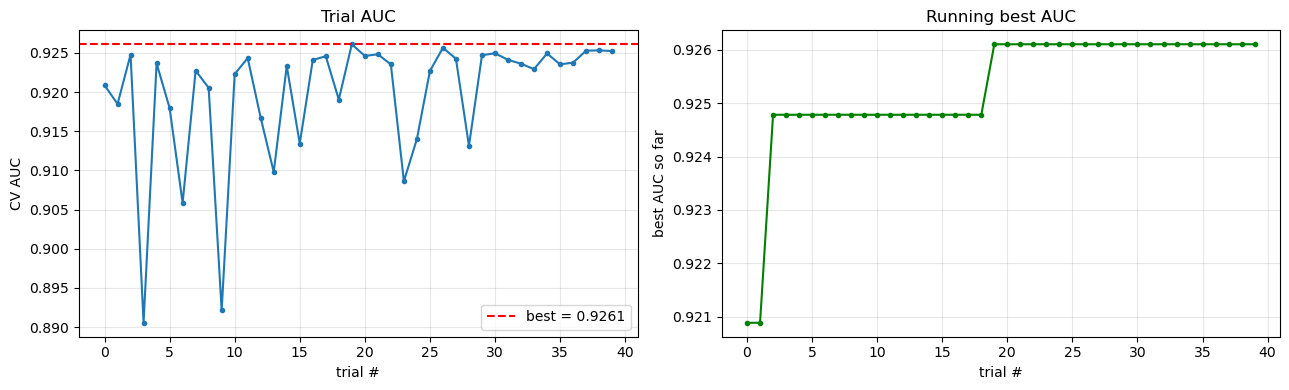

In [10]:
# Optuna study diagnostics — the value plot shows whether more trials would help.
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
vals = [t.value for t in study.trials if t.value is not None]
ax[0].plot(vals, marker=".")
ax[0].axhline(study.best_value, color="red", ls="--", label=f"best = {study.best_value:.4f}")
ax[0].set(title="Trial AUC", xlabel="trial #", ylabel="CV AUC")
ax[0].legend()
ax[0].grid(alpha=0.3)

running_best = np.maximum.accumulate(vals)
ax[1].plot(running_best, marker=".", color="green")
ax[1].set(title="Running best AUC", xlabel="trial #", ylabel="best AUC so far")
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Train the final model on all of training data

Re-fit a fresh XGBoost with the Optuna-selected hyper-parameters on the entire training set, then inspect the in-sample report plus feature importances. (The honest performance estimate is the CV AUC reported above — this section is just a sanity check.)

In [11]:
best_model = xgb.XGBClassifier(
    **study.best_params,
    eval_metric="auc",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)
final_pipe = Pipeline([("prep", preprocessor), ("model", best_model)])
final_pipe.fit(X, y)

train_probs = final_pipe.predict_proba(X)[:, 1]
train_preds = (train_probs >= 0.5).astype(int)

print(f"Training AUC      : {roc_auc_score(y, train_probs):.4f}")
print(f"Training accuracy : {accuracy_score(y, train_preds):.4f}")
print(f"Training F1       : {f1_score(y, train_preds):.4f}")
print("\nConfusion matrix (train):")
print(confusion_matrix(y, train_preds))
print("\nClassification report (train):")
print(classification_report(y, train_preds, digits=4))

Training AUC      : 0.9601
Training accuracy : 0.8906
Training F1       : 0.8907

Confusion matrix (train):
[[3092  360]
 [ 401 3101]]

Classification report (train):
              precision    recall  f1-score   support

           0     0.8852    0.8957    0.8904      3452
           1     0.8960    0.8855    0.8907      3502

    accuracy                         0.8906      6954
   macro avg     0.8906    0.8906    0.8906      6954
weighted avg     0.8906    0.8906    0.8906      6954



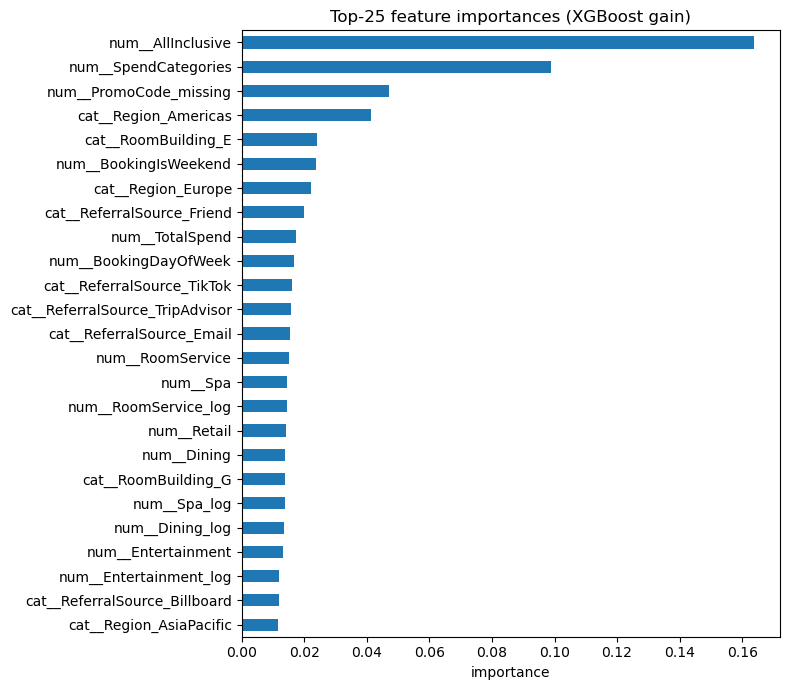

In [12]:
# Top-25 feature importances from the tuned XGBoost model.
feature_names = final_pipe.named_steps["prep"].get_feature_names_out()
importances = final_pipe.named_steps["model"].feature_importances_
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(8, 7))
fi[::-1].plot(kind="barh", ax=ax)
ax.set_title("Top-25 feature importances (XGBoost gain)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

## 8. Predict on the test set + write `submission.csv`

We threshold predicted probabilities at 0.5 to produce hard 0/1 labels as required, then write a two-column `GuestID,Churned` file next to the notebook.

In [13]:
test_probs = final_pipe.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

submission = pd.DataFrame({
    "GuestID": test_fe[ID_COL].values,
    "Churned": test_preds,
})
submission.to_csv("submission.csv", index=False)

print(f"Wrote submission.csv with {len(submission)} rows")
print(f"Predicted churn rate: {submission['Churned'].mean():.2%}")
submission.head()

Wrote submission.csv with 1739 rows
Predicted churn rate: 48.07%


,GuestID,Churned
0,154038,1
1,620160,0
2,655103,0
3,126993,0
4,635228,0


## 9. Notes for future iterations

* **Threshold tuning.** We hard-coded 0.5 because the deliverable wants {0,1}. If the grader uses F1 or business cost, sweep the threshold on out-of-fold predictions and pick the operating point that maximises that metric.
* **More trials.** TPE keeps improving with more samples. 80–150 trials usually squeezes another 1–2 AUC points out without changing the search space.
* **More feature engineering.** Promising directions: interactions between `Region` and `PackageType`, ratios like `Spa / TotalSpend`, and treating `RoomNumber` modulo per-building floor counts.
* **Stacking.** Average the tuned XGBoost with a tuned `LogisticRegression` on the same preprocessor — these two often disagree on different rows, so a simple average tends to nudge AUC up.